# **Problem Statement**

## Business Context

Renewable energy sources play an increasingly important role in the global energy mix, as the effort to reduce the environmental impact of energy production increases.

Out of all the renewable energy alternatives, wind energy is one of the most developed technologies worldwide. The U.S Department of Energy has put together a guide to achieving operational efficiency using predictive maintenance practices.

Predictive maintenance uses sensor information and analysis methods to measure and predict degradation and future component capability. The idea behind predictive maintenance is that failure patterns are predictable and if component failure can be predicted accurately and the component is replaced before it fails, the costs of operation and maintenance will be much lower.

The sensors fitted across different machines involved in the process of energy generation collect data related to various environmental factors (temperature, humidity, wind speed, etc.) and additional features related to various parts of the wind turbine (gearbox, tower, blades, break, etc.).

## Objective

“ReneWind” is a company working on improving the machinery/processes involved in the production of wind energy using machine learning and has collected data of generator failure of wind turbines using sensors. They have shared a ciphered version of the data, as the data collected through sensors is confidential (the type of data collected varies with companies). Data has 40 predictors, 20000 observations in the training set and 5000 in the test set.

The objective is to build various classification models, tune them, and find the best one that will help identify failures so that the generators could be repaired before failing/breaking to reduce the overall maintenance cost.
The nature of predictions made by the classification model will translate as follows:

- True positives (TP) are failures correctly predicted by the model. These will result in repairing costs.
- False negatives (FN) are real failures where there is no detection by the model. These will result in replacement costs.
- False positives (FP) are detections where there is no failure. These will result in inspection costs.

It is given that the cost of repairing a generator is much less than the cost of replacing it, and the cost of inspection is less than the cost of repair.

“1” in the target variables should be considered as “failure” and “0” represents “No failure”.

## Data Description

The data provided is a transformed version of the original data which was collected using sensors.

- Train.csv - To be used for training and tuning of models.
- Test.csv - To be used only for testing the performance of the final best model.

Both the datasets consist of 40 predictor variables and 1 target variable.

# **Installing and Importing the necessary libraries**

In [120]:
# Installing the libraries with the specified version
!pip install --no-deps tensorflow==2.19.0 scikit-learn==1.6.1 matplotlib===3.10.0 seaborn==0.13.2 numpy==2.0.2 pandas==2.2.2 -q --user --no-warn-script-location

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

# **Loading the Data**

In [123]:
# uncomment and run the following lines for Google Colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [124]:
import pandas as pd  # Library for data manipulation and analysis.
import numpy as np   # Fundamental package for scientific computing.
import matplotlib.pyplot as plt  # Plotting library for creating visualizations.
import seaborn as sns #For advanced visualizations.

# Function for splitting datasets for training and testing.
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import time  # Module for time-related operations.

# Import MinMaxScaler for feature scaling.
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf #An end-to-end open source machine learning platform
from tensorflow import keras  # High-level neural networks API for deep learning.
from keras import backend   # Abstraction layer for neural network backend engines.
from keras.models import Sequential  # Model for building NN sequentially.
from keras.layers import Dense, Dropout, BatchNormalization, Input

# to suppress warnings
import warnings
warnings.filterwarnings("ignore")

# **Data Overview**

In [125]:
# loading data into a pandas dataframe
data_train = pd.read_csv("/content/drive/My Drive/Python-Course/aiml-project4/Train.csv")
data_test = pd.read_csv("/content/drive/My Drive/Python-Course/aiml-project4/Test.csv")

In this step, we will:

- Check how many rows and columns are in the dataset
- Look at the first few rows to get a feel for the data
- See what data types each column has
- Check for any missing

In [126]:
data_train.head(10)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-4.464606,-4.679129,3.101546,0.506130,-0.221083,-2.032511,-2.910870,0.050714,-1.522351,3.761892,...,3.059700,-1.690440,2.846296,2.235198,6.667486,0.443809,-2.369169,2.950578,-3.480324,0
1,3.365912,3.653381,0.909671,-1.367528,0.332016,2.358938,0.732600,-4.332135,0.565695,-0.101080,...,-1.795474,3.032780,-2.467514,1.894599,-2.297780,-1.731048,5.908837,-0.386345,0.616242,0
2,-3.831843,-5.824444,0.634031,-2.418815,-1.773827,1.016824,-2.098941,-3.173204,-2.081860,5.392621,...,-0.257101,0.803550,4.086219,2.292138,5.360850,0.351993,2.940021,3.839160,-4.309402,0
3,1.618098,1.888342,7.046143,-1.147285,0.083080,-1.529780,0.207309,-2.493629,0.344926,2.118578,...,-3.584425,-2.577474,1.363769,0.622714,5.550100,-1.526796,0.138853,3.101430,-1.277378,0
4,-0.111440,3.872488,-3.758361,-2.982897,3.792714,0.544960,0.205433,4.848994,-1.854920,-6.220023,...,8.265896,6.629213,-10.068689,1.222987,-3.229763,1.686909,-2.163896,-3.644622,6.510338,0
5,0.159623,-4.233781,-0.264310,-5.477119,-0.190854,-0.356274,-0.134486,4.066608,-3.858569,1.692441,...,3.227235,0.628900,-1.548860,1.321979,5.461345,1.109410,-3.869993,0.273964,2.805941,0
6,-0.184565,-4.721470,0.864988,-3.078695,-2.226888,-1.282220,-0.804717,3.289733,-1.567971,0.749904,...,-0.544941,-0.762921,0.815558,1.889373,3.624347,1.555740,-5.432884,0.678703,0.464697,0
7,1.734840,1.682945,-1.269070,4.600630,-1.416975,-2.543916,0.131648,-0.198661,3.094057,-1.109324,...,1.717474,-3.838931,1.569448,1.794899,-4.268517,-0.516195,-0.619218,-0.830889,-4.967266,1
8,1.781583,1.314664,4.248690,-0.518293,-0.149044,0.033082,-1.087893,-3.117561,0.624935,1.567455,...,1.611014,2.951390,-1.862016,4.389598,1.371300,-2.516235,0.770496,0.831132,-2.310953,0
9,-0.894140,4.011498,5.251902,3.320747,0.727067,-4.771070,1.031232,3.632080,-1.391444,-1.966746,...,-0.635742,-4.449139,2.296340,1.575110,1.376268,0.596757,-1.413652,0.543871,0.035020,0


In [127]:
data_test.head(10)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-0.613489,-3.819640,2.202302,1.300420,-1.184929,-4.495964,-1.835817,4.722989,1.206140,-0.341909,...,2.291204,-5.411388,0.870073,0.574479,4.157191,1.428093,-10.511342,0.454664,-1.448363,0
1,0.389608,-0.512341,0.527053,-2.576776,-1.016766,2.235112,-0.441301,-4.405744,-0.332869,1.966794,...,-2.474936,2.493582,0.315165,2.059288,0.683859,-0.485452,5.128350,1.720744,-1.488235,0
2,-0.874861,-0.640632,4.084202,-1.590454,0.525855,-1.957592,-0.695367,1.347309,-1.732348,0.466500,...,-1.318888,-2.997464,0.459664,0.619774,5.631504,1.323512,-1.752154,1.808302,1.675748,0
3,0.238384,1.458607,4.014528,2.534478,1.196987,-3.117330,-0.924035,0.269493,1.322436,0.702345,...,3.517918,-3.074085,-0.284220,0.954576,3.029331,-1.367198,-3.412140,0.906000,-2.450889,0
4,5.828225,2.768260,-1.234530,2.809264,-1.641648,-1.406698,0.568643,0.965043,1.918379,-2.774855,...,1.773841,-1.501573,-2.226702,4.776830,-6.559698,-0.805551,-0.276007,-3.858207,-0.537694,0
5,-1.885713,-1.964160,0.245667,-1.187255,0.027369,-2.214094,-0.605558,3.434368,-2.366542,0.238592,...,3.481445,-1.241937,0.165481,1.938014,3.174898,1.513700,-2.634459,0.694483,-0.169500,0
6,-1.836429,1.216661,-0.186460,0.232731,1.752135,-1.982141,0.637039,3.654029,-2.891643,-0.882726,...,3.697508,-1.371313,-0.267922,0.385374,1.392039,1.195155,0.104975,-0.258228,1.581771,0
7,-1.649117,0.646787,2.657947,1.395099,0.725959,0.305211,-1.877257,-3.814487,2.273639,0.434063,...,-1.082314,0.530939,-0.290736,-0.219059,1.364707,-0.565783,0.605945,1.772588,-1.977966,0
8,-2.744431,-5.870927,1.169155,-1.586454,-2.215360,-3.561773,-2.037385,2.782849,-0.687223,1.527678,...,0.172074,-5.489960,3.224386,1.433453,6.421956,3.016854,-5.953351,3.084918,-2.982987,0
9,-0.247320,-1.130009,4.584899,0.051528,0.044828,-2.527062,-1.643095,1.042020,-0.059002,0.751700,...,1.133185,-2.171650,-0.245509,2.071918,4.719610,0.033392,-4.396785,1.221412,-0.531737,0


- Train and test dataset matches

### Checking the shape of the dataset of train and test

In [128]:
data_train.shape

(20000, 41)

In [129]:
data_test.shape

(5000, 41)

- The train data consists of 20000 rows and 41 columns
- The test data consists of 5000 rows and 41 columns

### Data types of the columns of the dataset

In [130]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      19982 non-null  float64
 1   V2      19982 non-null  float64
 2   V3      20000 non-null  float64
 3   V4      20000 non-null  float64
 4   V5      20000 non-null  float64
 5   V6      20000 non-null  float64
 6   V7      20000 non-null  float64
 7   V8      20000 non-null  float64
 8   V9      20000 non-null  float64
 9   V10     20000 non-null  float64
 10  V11     20000 non-null  float64
 11  V12     20000 non-null  float64
 12  V13     20000 non-null  float64
 13  V14     20000 non-null  float64
 14  V15     20000 non-null  float64
 15  V16     20000 non-null  float64
 16  V17     20000 non-null  float64
 17  V18     20000 non-null  float64
 18  V19     20000 non-null  float64
 19  V20     20000 non-null  float64
 20  V21     20000 non-null  float64
 21  V22     20000 non-null  float64
 22

In [131]:
data_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      4995 non-null   float64
 1   V2      4994 non-null   float64
 2   V3      5000 non-null   float64
 3   V4      5000 non-null   float64
 4   V5      5000 non-null   float64
 5   V6      5000 non-null   float64
 6   V7      5000 non-null   float64
 7   V8      5000 non-null   float64
 8   V9      5000 non-null   float64
 9   V10     5000 non-null   float64
 10  V11     5000 non-null   float64
 11  V12     5000 non-null   float64
 12  V13     5000 non-null   float64
 13  V14     5000 non-null   float64
 14  V15     5000 non-null   float64
 15  V16     5000 non-null   float64
 16  V17     5000 non-null   float64
 17  V18     5000 non-null   float64
 18  V19     5000 non-null   float64
 19  V20     5000 non-null   float64
 20  V21     5000 non-null   float64
 21  V22     5000 non-null   float64
 22  

- Very few vaules are missing in both test and train dataset

In [132]:
data_train.describe().T

,count,mean,std,min,25%,50%,75%,max
V1,19982.0,-0.271996,3.441625,-11.876451,-2.737146,-0.747917,1.840112,15.493002
V2,19982.0,0.440430,3.150784,-12.319951,-1.640674,0.471536,2.543967,13.089269
V3,20000.0,2.484699,3.388963,-10.708139,0.206860,2.255786,4.566165,17.090919
V4,20000.0,-0.083152,3.431595,-15.082052,-2.347660,-0.135241,2.130615,13.236381
V5,20000.0,-0.053752,2.104801,-8.603361,-1.535607,-0.101952,1.340480,8.133797
V6,20000.0,-0.995443,2.040970,-10.227147,-2.347238,-1.000515,0.380330,6.975847
V7,20000.0,-0.879325,1.761626,-7.949681,-2.030926,-0.917179,0.223695,8.006091
V8,20000.0,-0.548195,3.295756,-15.657561,-2.642665,-0.389085,1.722965,11.679495
V9,20000.0,-0.016808,2.160568,-8.596313,-1.494973,-0.067597,1.409203,8.137580
V10,20000.0,-0.012998,2.193201,-9.853957,-1.411212,0.100973,1.477045,8.108472


In [133]:
(data_test.isnull().sum() / len(data_test)) * 100

,0
V1,0.10
V2,0.12
V3,0.00
V4,0.00
V5,0.00
V6,0.00
V7,0.00
V8,0.00
V9,0.00
V10,0.00


In [134]:
(data_train.isnull().sum() / len(data_train)) * 100

,0
V1,0.09
V2,0.09
V3,0.00
V4,0.00
V5,0.00
V6,0.00
V7,0.00
V8,0.00
V9,0.00
V10,0.00


- Train dataset: v1 and v2 ~ 0.09% values are missing
- Test dataset: v1 and v2 ~ 0.10% values are missing
- Both are very minimal and it is safe to drop missing value

In [135]:

# Step 1: Create a copy
df_test = data_test.copy()
df_train = data_train.copy()

In [136]:
# Step 2: Drop missing values
df_test.dropna(inplace=True)
df_train.dropna(inplace=True)

# **Exploratory Data Analysis**

## Univariate analysis

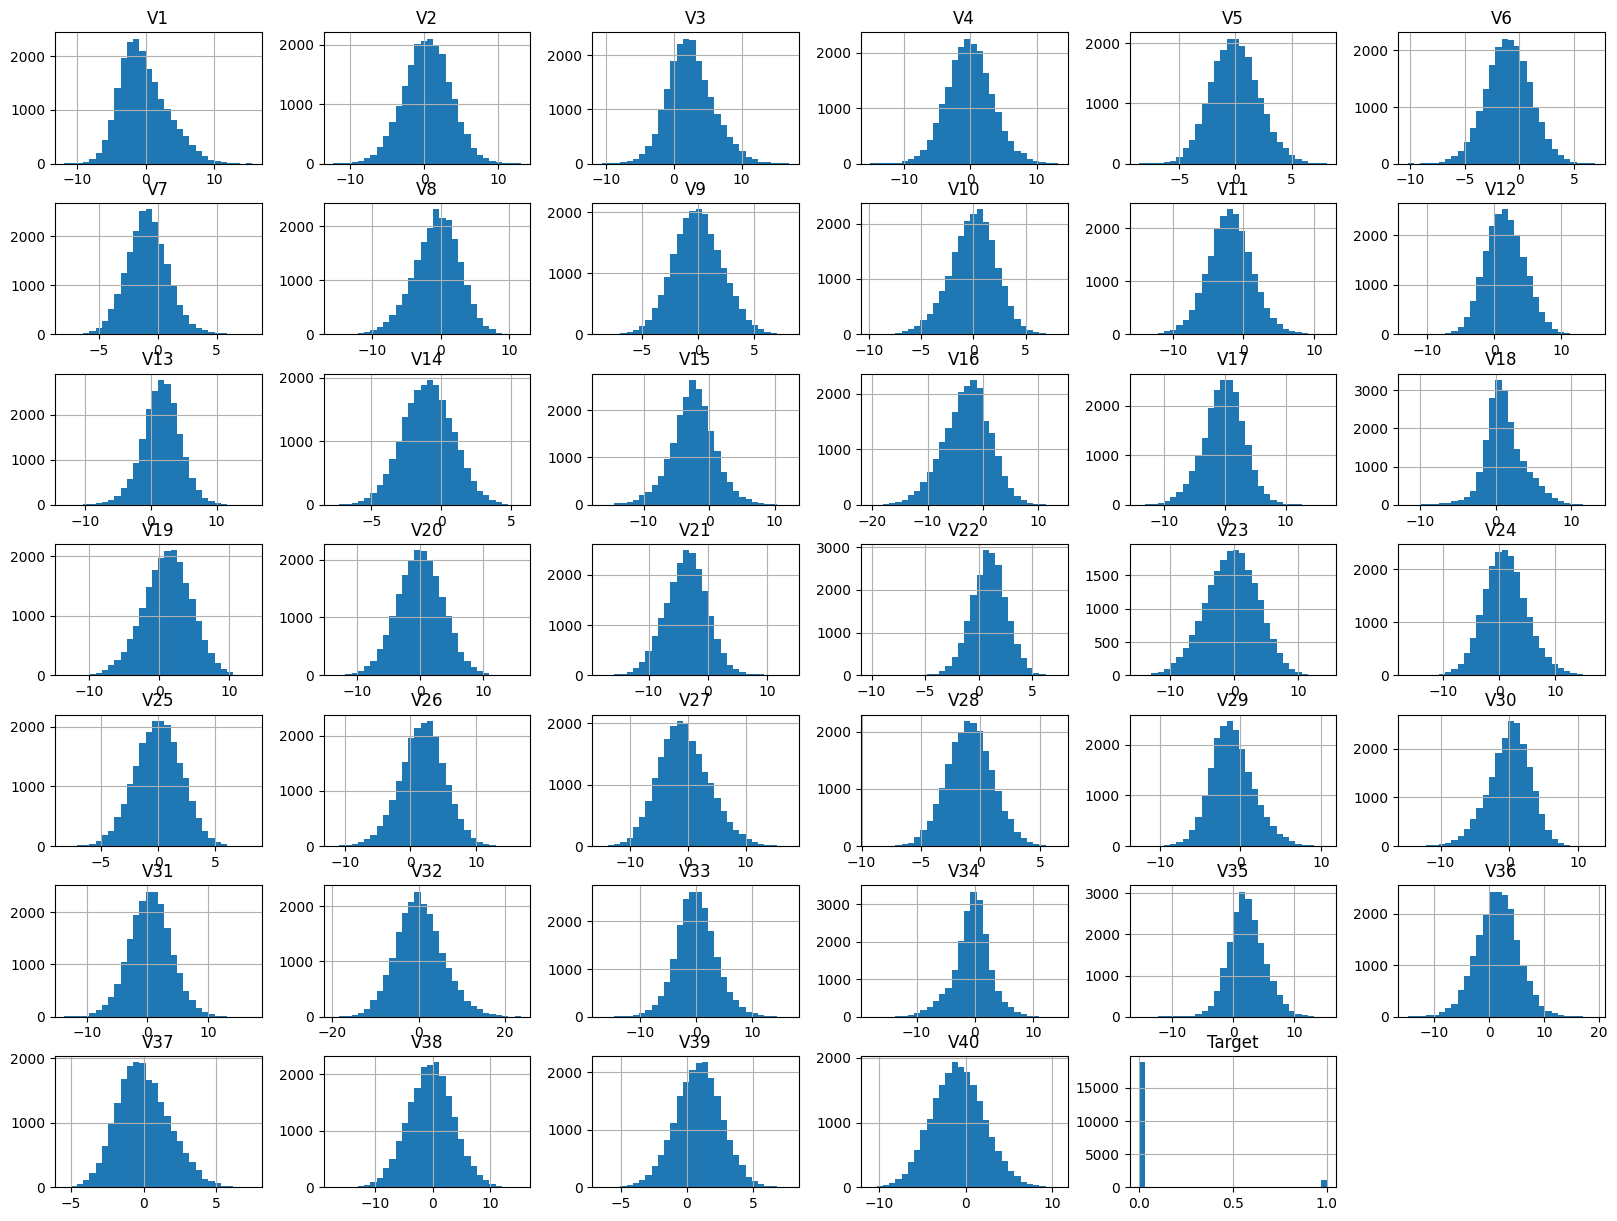

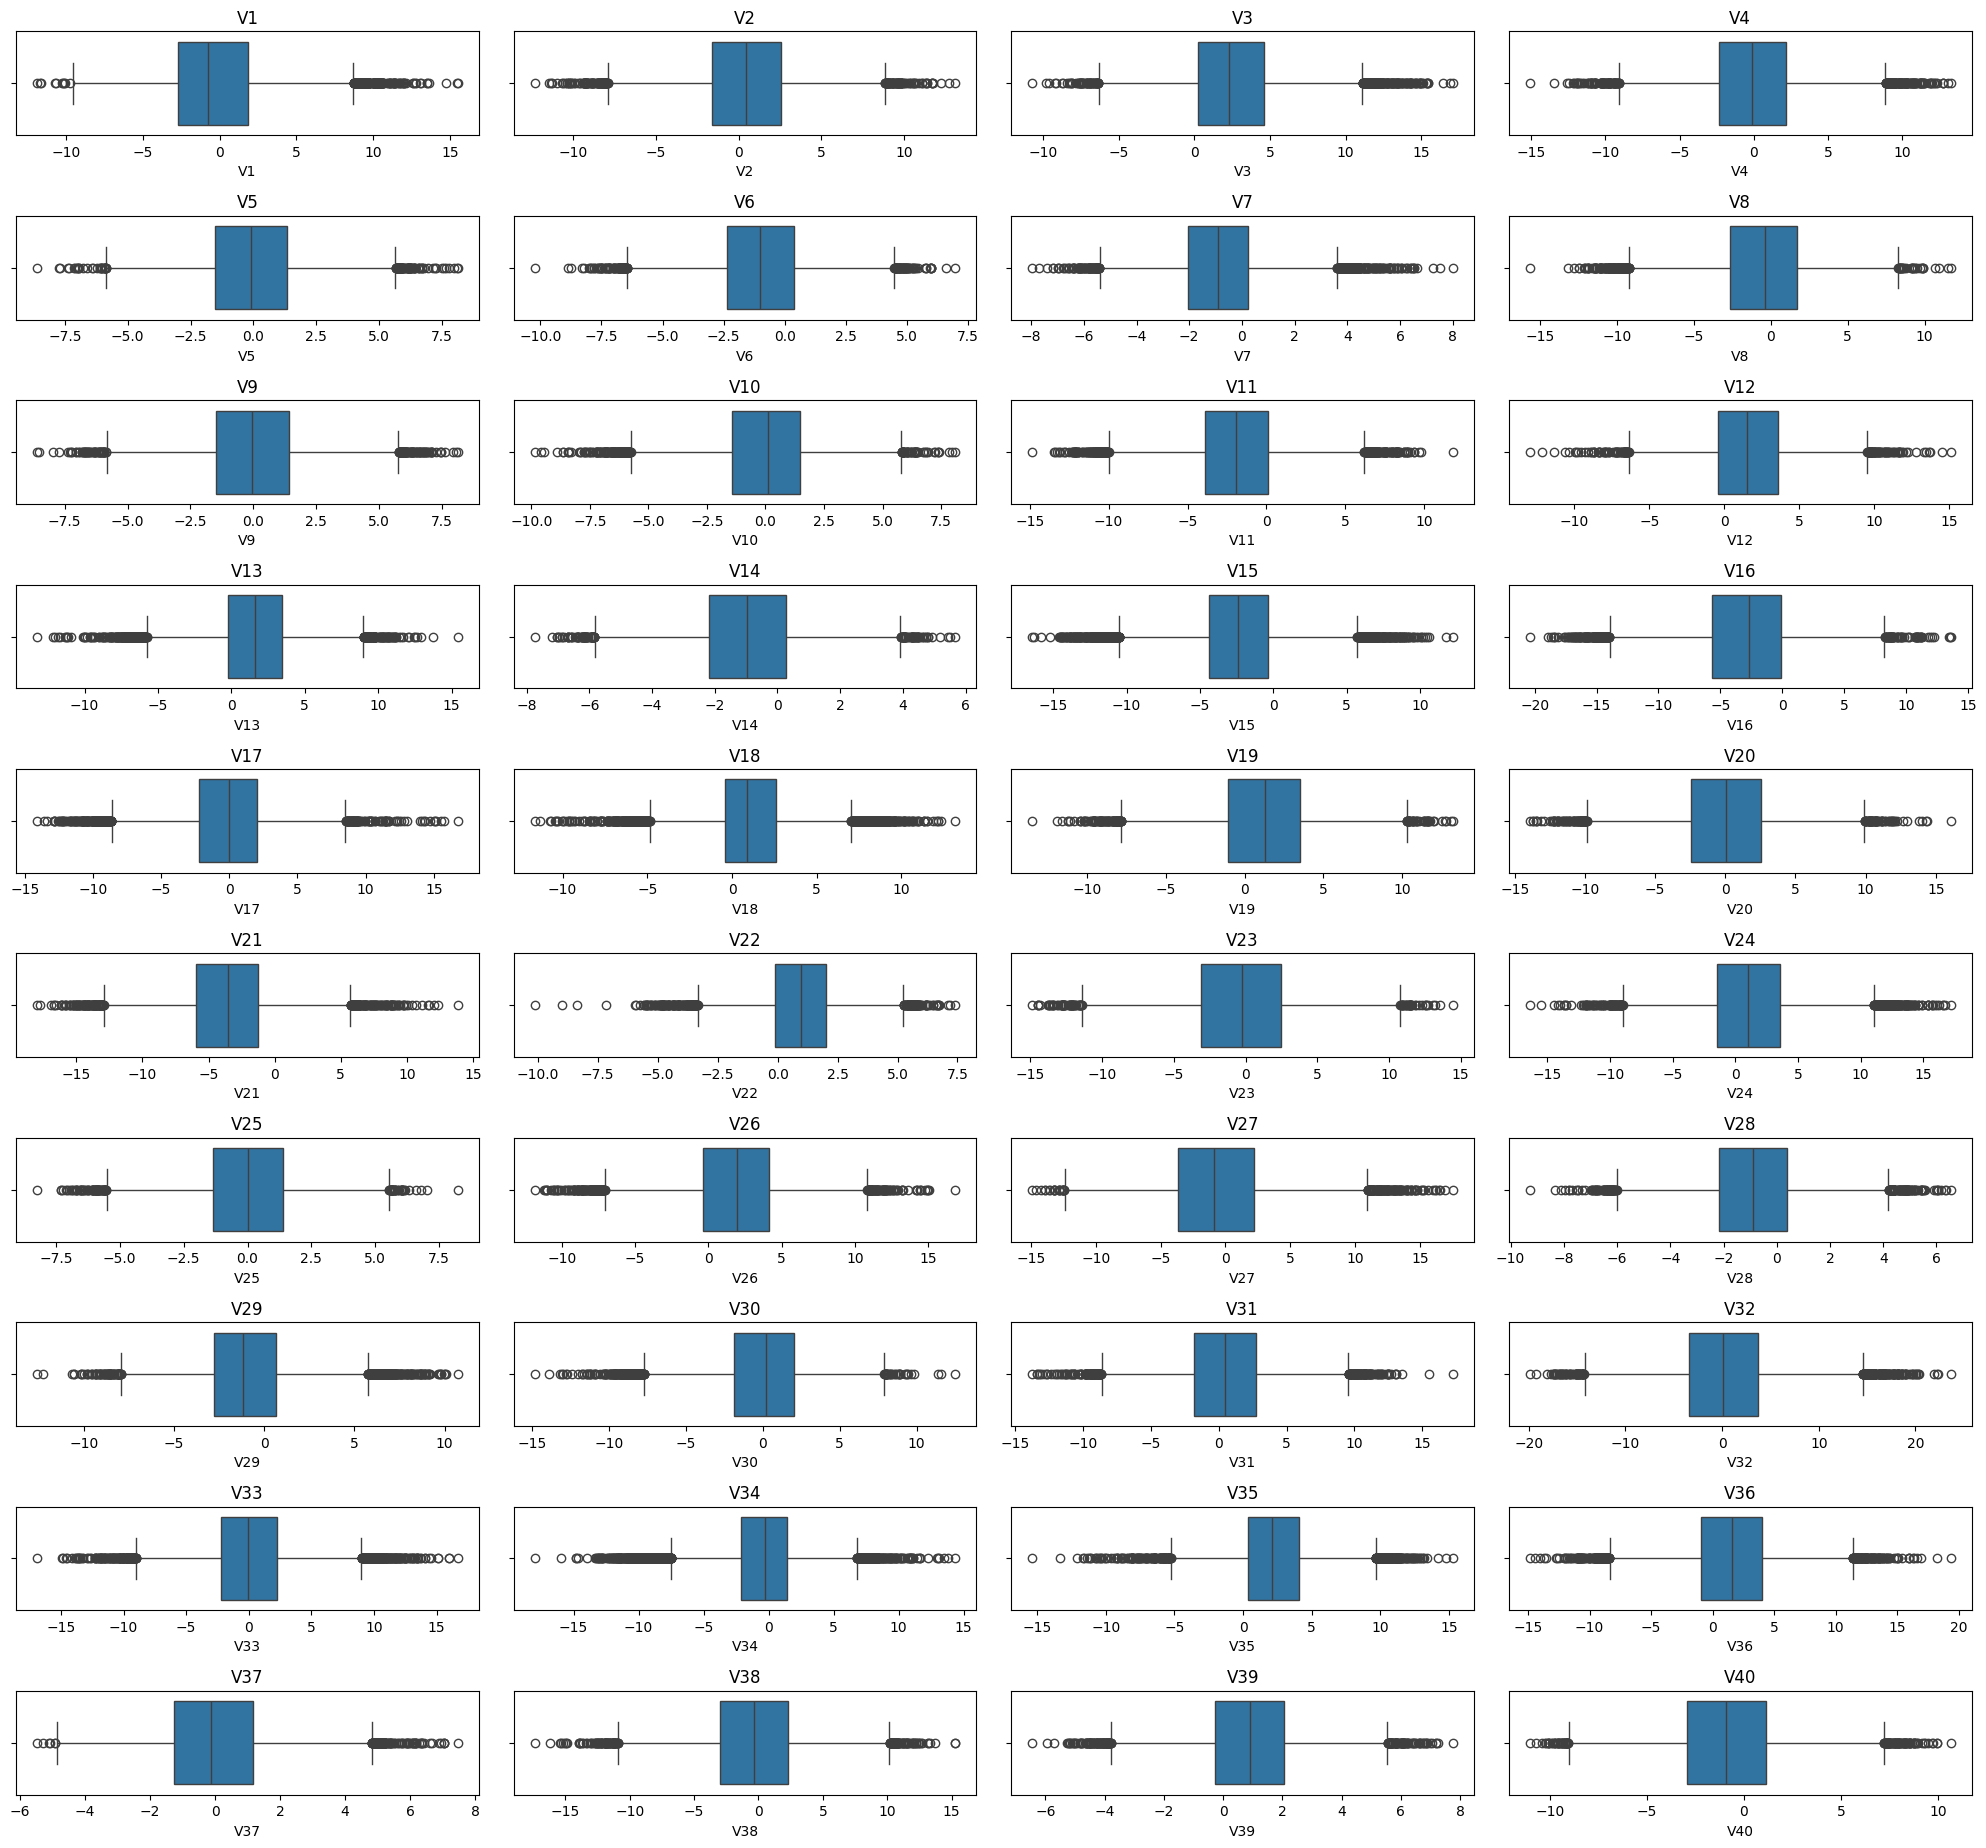

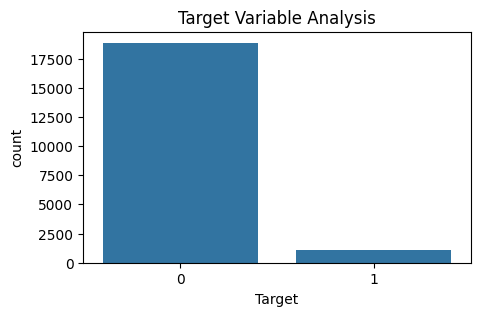

Target
0    18854
1     1110
Name: count, dtype: int64


In [137]:

# Histogram for all features
df_train.hist(figsize=(20, 15), bins=30)
plt.show()


# Boxplot (Detect Outliers)
features = df_train.columns[:-1] #exclude Target column

# set grid size (adjust based on number of features)
n_cols = 4
n_rows = int(len(features) / n_cols) + 1

plt.figure(figsize=(20, 20))

for i, col in enumerate(features, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df_train[col])
    plt.title(col)

plt.tight_layout()
plt.show()


# Target Variable Analysis
plt.figure(figsize=(5,3))
sns.countplot(x='Target', data=df_train)
plt.title("Target Variable Analysis")
plt.show()

print(df_train['Target'].value_counts())


### Observation

1. Feature Distribution

- Most features (V1–V40) show continuous numerical distribution
- Variables appear normally distributed, but some are skewed
- A few features show wide value ranges, indicating variability in data

2. Presence of Outliers

- Boxplots reveal significant outliers in many features
- Some variables have extreme positive or negative values

3. Features have different ranges and magnitudes. Some between (-5 to 5)

4. The target variable is binary and imbalanced, which should be considered while training the model.
  - Negative: 0    18854
  - Positive: 1     1110

5. All features are numerical. No encoding required.



## Bivariate Analysis

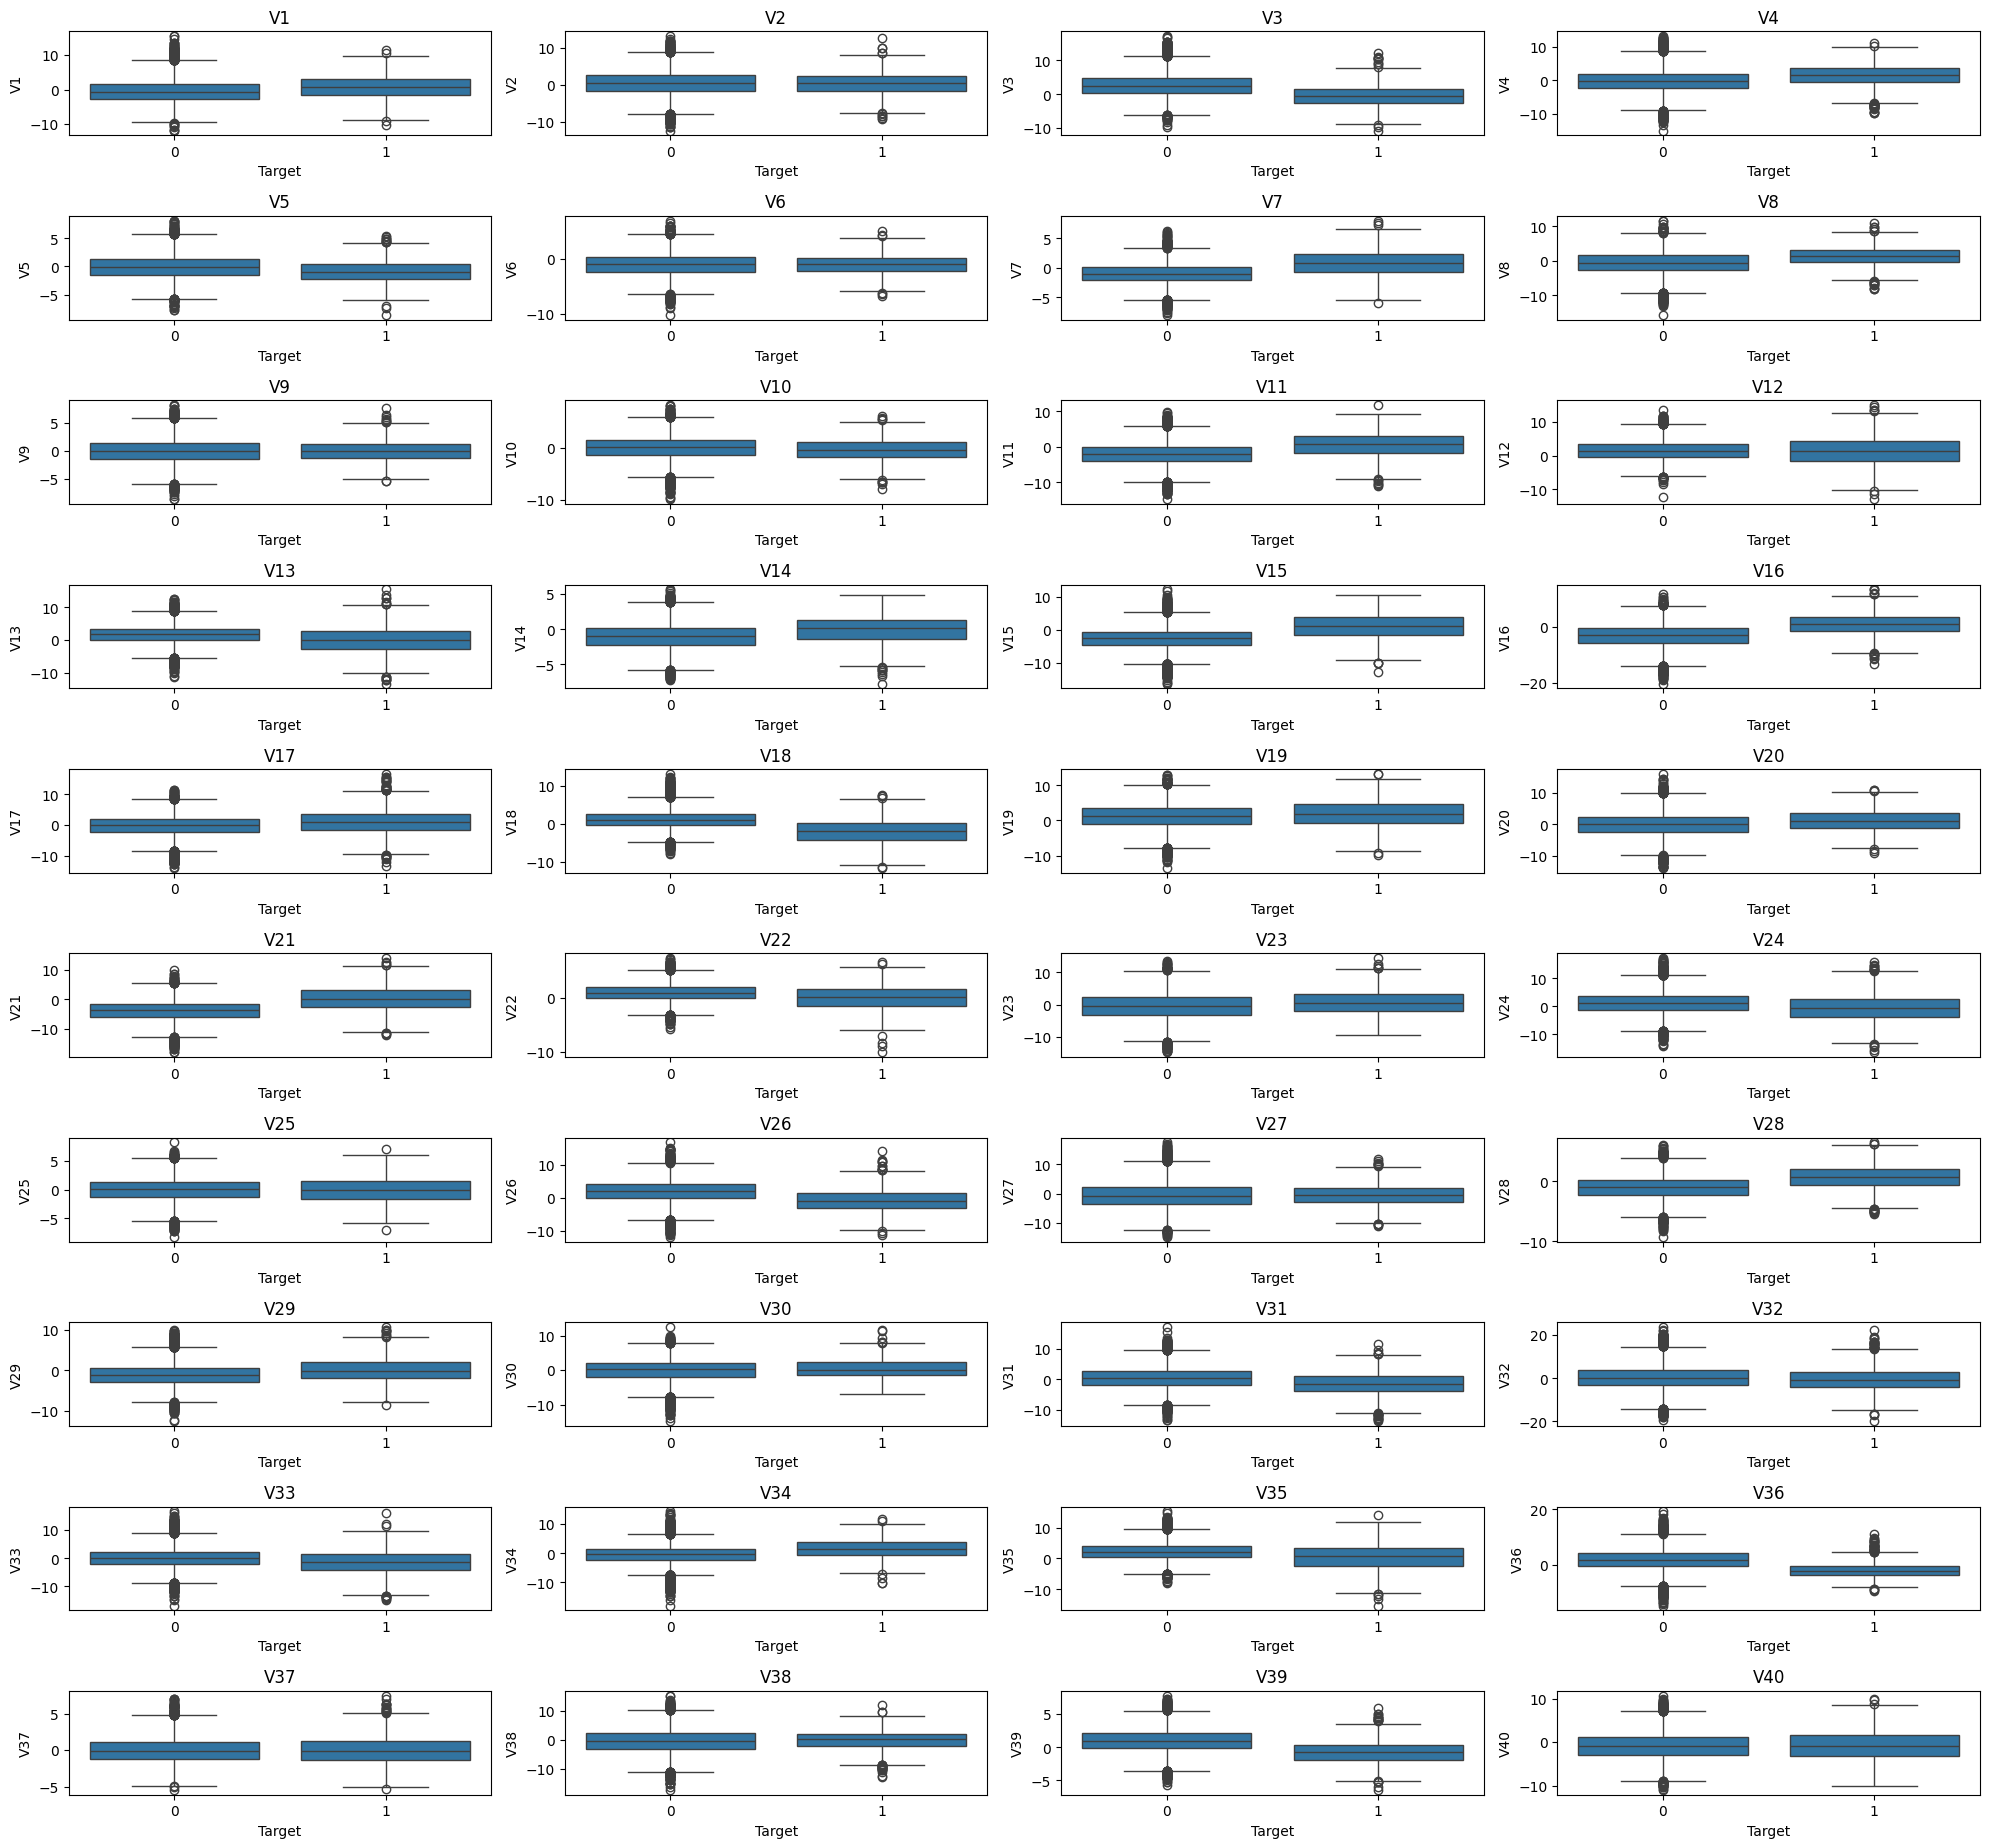

In [138]:

features = df_train.columns[:-1]

n_cols = 4
n_rows = int(len(features) / n_cols) + 1

plt.figure(figsize=(20, 20))

for i, col in enumerate(features, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x='Target', y=col, data=df_train)
    plt.title(col)

plt.tight_layout()
plt.show()


### Observations

Eg `V10, V14, V20, V30, V35`

- Show clearly different medians for Target = 0 vs Target = 1
- The interquartile range (box region) overlaps very little or moderately
- Distribution shifts in either positive or negative direction
- Shows a clear difference in median values between target classes with relatively less overlap in their distributions, indicating strong predictive power.

Eg `V3, V7, V15, V26, V33`

- Have slight difference in medians
- Displays moderate separation with some overlap, suggesting they contribute partially to classification.
- Distribution shapes vary across classes, meaning features are useful but not dominant

Eg `V1, V2, V5, V6, V8, V12`

- Nearly identical medians for both classes
- Heavy overlap of distributions, no visible shift between Target 0 and 1
- May have low importance in the model
- Shows significant overlap between target classes, indicating low individual predictive capability.

Eg `V20, V35`

- Outliers are present across both target classes.
- Suggesting they do not contribute significantly to class separation.

Overall, outliers are observed in both classes across multiple features. No single feature can perfectly distinguish the target classes, and classification depends on the combined effect of multiple variables.




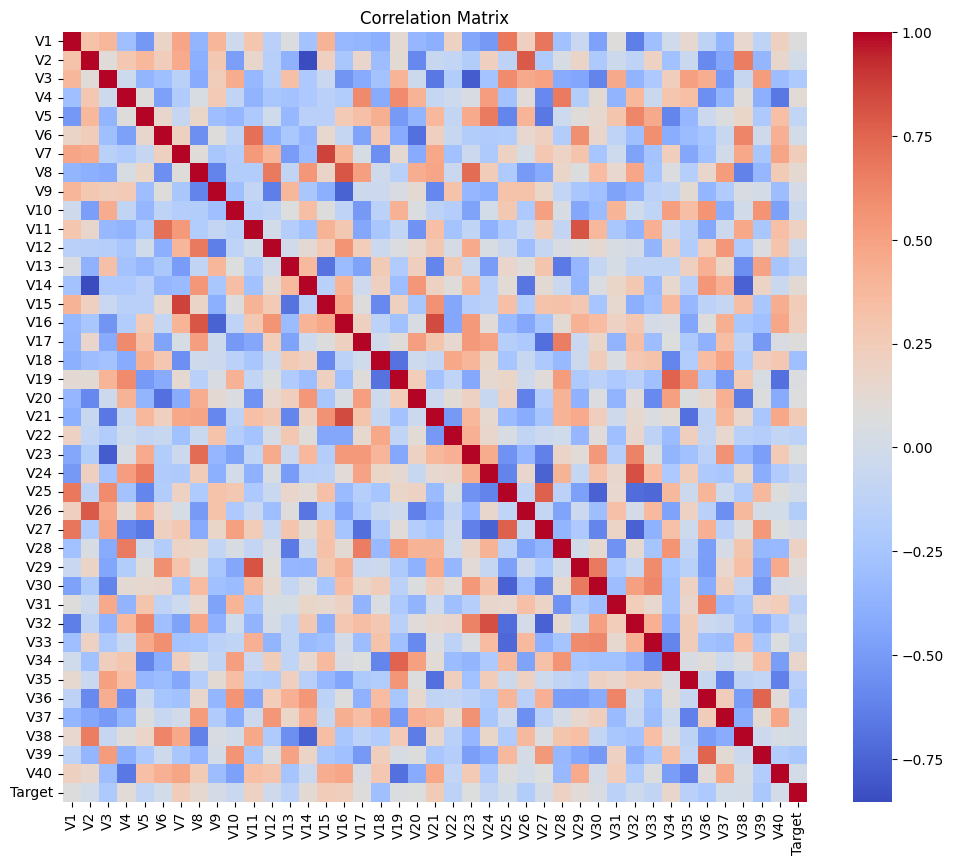

In [139]:

plt.figure(figsize=(12,10))
corr = df_train.corr()

sns.heatmap(corr, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


### Observation

- Most features exhibit low correlation with each other, indicating minimal redundancy and suggesting that the dataset has largely independent variables
- E.g, V7-V15, V8-V16, V9-16, V3-V23, V14-V2, V25- V23, V25-V24, V27-V23, V27-V24 type pattern pairs show strong positive or negative correlation, indicating possible multicollinearity and redundancy in information
- Strong correlations are limited to only a few feature pairs
- The correlation of individual features with the target variable is generally low to moderate, indicating that no single feature alone can strongly predict the target
- Both positive and negative correlations with the target variable are observed, suggesting that features influence the target in different ways


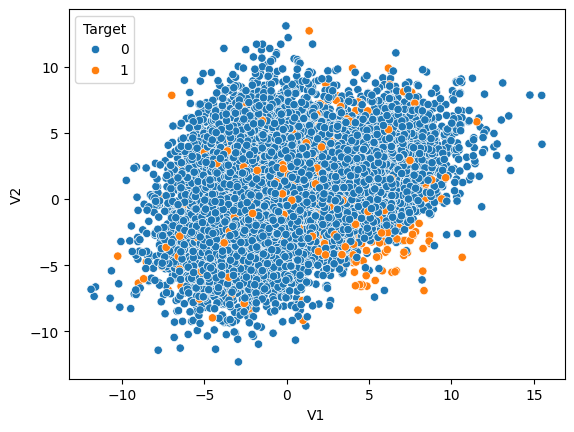

In [140]:

sns.scatterplot(x='V1', y='V2', hue='Target', data=df_train)
plt.show()


### Observations:

- The scatter plots show partial clustering of data points based on the target variable, indicating that certain feature combinations help differentiate between classes.
- Points are scattered randomly; Data points are concentrated in certain regions while sparse in others, indicating uneven distribution across feature space.


# **Data Preprocessing**

#### Training, Validation and: testing the dataset

- Feature engineering - All are sensor details and plays critical role - Not a good idea to drop any.
- Outlier detection and treatment - Outlier treatement may require based on the model used, for this exercise not recommended
- Preparing data for modeling - No catacory columns hence not needed


In [216]:
# Split data into training, validation, and test sets
X = df_train.drop('Target', axis=1)
y = df_train['Target']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

#### Rescale all feature values to a fixed range


In [218]:

scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

X_test = df_test.drop("Target", axis=1)   # remove target
X_test = scaler.transform(X_test)        # scale


In [ ]:
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)

X_train shape: (13974, 40)
X_val shape: (2995, 40)
X_test shape: (2995, 40)
y_train shape: (13974,)
y_val shape: (2995,)
y_test shape: (2995,)


# **Model Building**

## Model Evaluation Criterion

| Outcome | Meaning                   | Cost                       |
|---------|---------------------------|----------------------------|
| TP      | Correctly predict failure | Repair cost(moderate).     |
| FN      | Missed Failure            | Very High cost             |
| FP      | False Alarm.              | Low Cost( inspection.      |

The evaluation criterion for this problem is primarily `Recall` for the failure class (class 1), as missing a failure (false negative) leads to significantly higher cost than unnecessary inspection.

Additionally, `F1-score` and `confusion matrix` are used for balanced evaluation, while a custom cost function is applied to align model selection with business impact.

`Accuracy` will take a back seat due to class imbalance.

### Utility functions

In [219]:
def plot(history, name):
    """
    Function to plot loss/accuracy

    history: an object which stores the metrics and losses.
    name: can be one of Loss or Accuracy
    """
    fig, ax = plt.subplots() #Creating a subplot with figure and axes.
    plt.plot(history.history[name]) #Plotting the train accuracy or train loss
    plt.plot(history.history['val_'+name]) #Plotting the validation accuracy or validation loss

    plt.title('Model ' + name.capitalize()) #Defining the title of the plot.
    plt.ylabel(name.capitalize()) #Capitalizing the first letter.
    plt.xlabel('Epoch') #Defining the label for the x-axis.
    fig.legend(['Train', 'Validation'], loc="outside right upper") #Defining the legend, loc controls the position of the legend.

Create a dataframe to store the results from all the models we build

In [220]:
evaluation_results = pd.DataFrame(columns=['Model', '# hidden layers', '# neurons hidden layer', 'activation function hidden layer', 'configuration', '# epochs', 'batch size', 'Train_Loss', 'Train_Accuracy', 'Train_Precision', 'Train_Recall', 'Train_F1',
                                         'Val_Loss', 'Val_Accuracy', 'Val_Precision', 'Val_Recall', 'Val_F1'])


In [221]:
evaluation_results

,Model,# hidden layers,# neurons hidden layer,activation function hidden layer,configuration,# epochs,batch size,Train_Loss,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Val_Loss,Val_Accuracy,Val_Precision,Val_Recall,Val_F1


## Initial Model Building (Model 0)

- Let's start with a neural network consisting of
  - Input Layer: The input shape is determined by the number of features in the training data, X_train​.
  - Just one hidden layer
  - Activation function of ReLU
  - SGD as the optimizer

In [222]:
# Clear the current Keras session, resetting all layers and models previously created if any.
tf.keras.backend.clear_session()

In [223]:
#Initializing the neural network
model0 = Sequential()

model0.add(Dense(20, activation='relu', input_shape=(X_train.shape[1],))) # Hidden Layer 1
model0.add(Dense(1, activation='sigmoid'))                    # Output Layer

In [224]:
#Printing the summary
model0.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │           820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 841 (3.29 KB)

 Trainable params: 841 (3.29 KB)

 Non-trainable params: 0 (0.00 B)

In [225]:
optimizer = 'sgd'   # defining SGD as the optimizer to be used
loss = 'binary_crossentropy'   # defining binary crossentropy as the loss function

#Compiling the model.
model0.compile(loss=loss, optimizer=optimizer, metrics=[tf.keras.metrics.Recall(), tf.keras.metrics.Precision(), tf.keras.metrics.BinaryAccuracy()])

In [226]:
epochs = 50   # training the model for 50 epochs
batch_size = 64    # Number of sample per update
start = time.time()

# Fitting the model.
wm_hist0 = model0.fit(X_train, y_train,
                      validation_data=(X_val,y_val) ,
                      batch_size=batch_size,
                      epochs=epochs)
end = time.time()

Epoch 1/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - binary_accuracy: 0.9415 - loss: 0.2927 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_binary_accuracy: 0.9444 - val_loss: 0.2253 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - binary_accuracy: 0.9444 - loss: 0.2223 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_binary_accuracy: 0.9444 - val_loss: 0.2203 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - binary_accuracy: 0.9444 - loss: 0.2190 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_binary_accuracy: 0.9444 - val_loss: 0.2176 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9444 - loss: 0.2166 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_binary_accuracy: 0.9444 - val_loss: 0.2154 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 5/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 

In [227]:
print("Time taken in seconds ",end-start)

Time taken in seconds  43.50308442115784


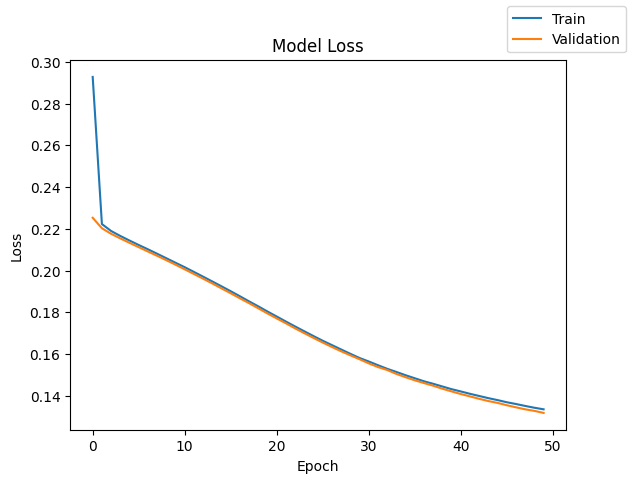

In [228]:
plot(wm_hist0,'loss')

In [229]:
evaluation_results.loc[0] = ['Model 0', '1', '[20]', 'ReLU', 'baseline', epochs, batch_size, wm_hist0.history["loss"][-1], wm_hist0.history["binary_accuracy"][-1], wm_hist0.history["precision"][-1], history0.history["recall"][-1], 2 * (history0.history["precision"][-1] * history0.history["recall"][-1]) / (history0.history["precision"][-1] + history0.history["recall"][-1] + 1e-7), history0.history["val_loss"][-1], history0.history["val_binary_accuracy"][-1], history0.history["val_precision"][-1], history0.history["val_recall"][-1], 2 * (history0.history["val_precision"][-1] * history0.history["val_recall"][-1]) / (history0.history["val_precision"][-1] + history0.history["val_recall"][-1] + 1e-7)]
evaluation_results

,Model,# hidden layers,# neurons hidden layer,activation function hidden layer,configuration,# epochs,batch size,Train_Loss,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Val_Loss,Val_Accuracy,Val_Precision,Val_Recall,Val_F1
0,Model 0,1,[20],ReLU,baseline,50,64,0.133644,0.954415,0.857143,0.213642,0.345833,0.143541,0.952254,0.928571,0.155689,0.266667


- The Accuracy is HIGH which may not be important factor since we want to avoid model predicting false negative
- Recall Train: 0.2136, Test: 0.1557 - Model is detecting only ~15–21% of actual failures
- Presision is HIGH: when model predicts failure, it is usually correct, but it rarely predicts failure
- F1 score Train: 0.3458, Test: 0.2667 - Poor Recall score meaning imbalance between precision and recall
- Loss score is stable, no major overfitting
- Model is biased toward predicting NO FAILURE (class 0)

# **Model Performance Improvement**

## Model 1

Second neural network model with the following changes:

- The same architecture as the first model.
- We use a **momentum of 0.9** for the optimizer
- The model is trained for 50 epochs using a mini-batch gradient descent approach with a batch size of 64.
- Add one more hidden layer with 10 neural nodes.

**Loss Function:** We use Binary Crossentropy as the loss function, which is standard for binary classification problems.

**Optimizer:** We use Stochastic Gradient Descent (SGD) as the optimizer to adjust the network's weights during training.

**Metrics:** The model is evaluated using the Recall metric.

In [230]:
# clears the current Keras session, resetting all layers and models previously created.
tf.keras.backend.clear_session()

In [231]:
#Initializing the neural network
model1 = Sequential()

model1.add(Dense(20, activation='relu', input_shape=(X_train.shape[1],)))
model1.add(Dense(10, activation='relu'))
model1.add(Dense(1, activation='sigmoid'))

In [232]:
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │           820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,041 (4.07 KB)

 Trainable params: 1,041 (4.07 KB)

 Non-trainable params: 0 (0.00 B)

In [233]:
optimizer = tf.keras.optimizers.SGD(momentum=0.9)   # Adding momentum to accelerate learning
loss = 'binary_crossentropy'  # defining binary crossentropy as the loss function

model1.compile(loss=loss, optimizer=optimizer, metrics=[tf.keras.metrics.Recall(), tf.keras.metrics.Precision(), tf.keras.metrics.BinaryAccuracy()])

In [234]:
epochs = 50
batch_size = 64

start = time.time()
wm_hist1 = model1.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end = time.time()

Epoch 1/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - binary_accuracy: 0.9444 - loss: 0.2308 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_binary_accuracy: 0.9444 - val_loss: 0.1984 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9444 - loss: 0.1768 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_binary_accuracy: 0.9449 - val_loss: 0.1551 - val_precision: 1.0000 - val_recall: 0.0090
Epoch 3/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9533 - loss: 0.1400 - precision: 0.9079 - recall: 0.1776 - val_binary_accuracy: 0.9581 - val_loss: 0.1258 - val_precision: 0.8475 - val_recall: 0.3003
Epoch 4/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9608 - loss: 0.1235 - precision: 0.8589 - recall: 0.3526 - val_binary_accuracy: 0.9654 - val_loss: 0.1191 - val_precision: 0.8000 - val_recall: 0.5045
Epoch 5/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9639 - 

In [235]:
print("Time taken in seconds ",end-start)

Time taken in seconds  44.40608024597168


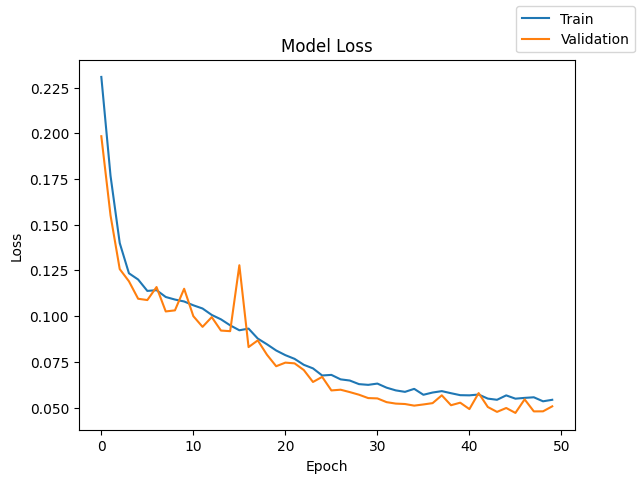

In [236]:
plot(wm_hist1,'loss')

In [237]:
evaluation_results.loc[1] = ['Model 1', '2', '[20, 10]', 'ReLU', 'momentum=0.9', epochs, batch_size, wm_hist1.history["loss"][-1], wm_hist1.history["binary_accuracy"][-1], wm_hist1.history["precision"][-1], wm_hist1.history["recall"][-1], 2 * (wm_hist1.history["precision"][-1] * wm_hist1.history["recall"][-1]) / (wm_hist1.history["precision"][-1] + wm_hist1.history["recall"][-1] + 1e-7), wm_hist1.history["val_loss"][-1], wm_hist1.history["val_binary_accuracy"][-1], wm_hist1.history["val_precision"][-1], wm_hist1.history["val_recall"][-1], 2 * (wm_hist1.history["val_precision"][-1] * wm_hist1.history["val_recall"][-1]) / (wm_hist1.history["val_precision"][-1] + wm_hist1.history["val_recall"][-1] + 1e-7)]
evaluation_results

,Model,# hidden layers,# neurons hidden layer,activation function hidden layer,configuration,# epochs,batch size,Train_Loss,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Val_Loss,Val_Accuracy,Val_Precision,Val_Recall,Val_F1
0,Model 0,1,[20],ReLU,baseline,50,64,0.133644,0.954415,0.857143,0.213642,0.345833,0.143541,0.952254,0.928571,0.155689,0.266667
1,Model 1,2,"[20, 10]",ReLU,momentum=0.9,50,64,0.054290,0.987835,0.973479,0.803089,0.880113,0.050716,0.988481,0.928571,0.858859,0.892356


- Detecting ~74% of failures vs only ~16% in Model 0. Huge reduction in False Negatives (FN)
- Improved balances precision + recall compared to model 0
- `0.99` Very HIGH Precision makes very accurate failure predictions
AND detects far more failures
- Captures more complex patterns; Better representation of sensor behavior
- Significantly outperforms Model 0 across all critical metrics, especially recall, making it far more suitable for predictive maintenance.
- The addition of a hidden layer and momentum-based SGD greatly improved the model’s ability to detect failures.

## Model 2

Third neural network model with the following changes:

- Same architecture as the baseline model. Use of Adam as the optimizer to automatically adjust the learning rate for each weight.

- Loss Function:Binary Crossentropy as the loss function, which is standard for binary classification problems.

- Optimizer: Adam as the optimizer for this model.

- Metrics: The model is evaluated using the Recall metric.

In [238]:
# clears the current Keras session, resetting all layers and models previously created.
tf.keras.backend.clear_session()

In [239]:
#Initializing the neural network
model2 = Sequential()
model2.add(Dense(20, activation='relu', input_shape=(X_train.shape[1],)))
model2.add(Dense(10, activation='relu'))
model2.add(Dense(1, activation='sigmoid'))

In [240]:
model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │           820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,041 (4.07 KB)

 Trainable params: 1,041 (4.07 KB)

 Non-trainable params: 0 (0.00 B)

In [241]:
optimizer = 'adam'   # defining ADAM as the optimizer to be used
loss = 'binary_crossentropy'
model2.compile(loss=loss, optimizer=optimizer, metrics=[tf.keras.metrics.Recall(), tf.keras.metrics.Precision(), tf.keras.metrics.BinaryAccuracy()])

In [242]:
epochs = 50
batch_size = 64

start = time.time()
wm_hist2 = model2.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end = time.time()

Epoch 1/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - binary_accuracy: 0.9438 - loss: 0.2667 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_binary_accuracy: 0.9444 - val_loss: 0.2049 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9444 - loss: 0.1876 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_binary_accuracy: 0.9444 - val_loss: 0.1647 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9497 - loss: 0.1464 - precision: 0.9302 - recall: 0.1030 - val_binary_accuracy: 0.9561 - val_loss: 0.1283 - val_precision: 0.9268 - val_recall: 0.2282
Epoch 4/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9596 - loss: 0.1249 - precision: 0.8790 - recall: 0.3179 - val_binary_accuracy: 0.9594 - val_loss: 0.1160 - val_precision: 0.8629 - val_recall: 0.3213
Epoch 5/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0

In [243]:
print("Time taken in seconds ",end-start)

Time taken in seconds  45.224278926849365


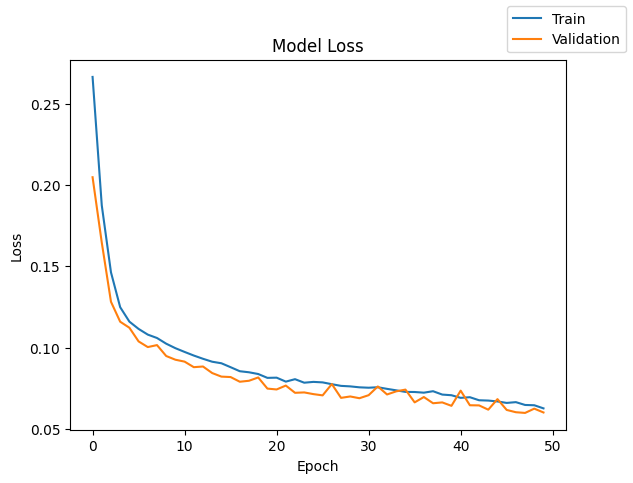

In [244]:
plot(wm_hist2,'loss')

In [245]:
evaluation_results.loc[2] = ['Model 2', '2', '[20, 10]', 'ReLU', 'optimizer=adam', epochs, batch_size, wm_hist2.history["loss"][-1], wm_hist2.history["binary_accuracy"][-1], wm_hist2.history["precision"][-1], wm_hist2.history["recall"][-1], 2 * (wm_hist2.history["precision"][-1] * wm_hist2.history["recall"][-1]) / (wm_hist2.history["precision"][-1] + wm_hist2.history["recall"][-1] + 1e-7), wm_hist2.history["val_loss"][-1], wm_hist2.history["val_binary_accuracy"][-1], wm_hist2.history["val_precision"][-1], wm_hist2.history["val_recall"][-1], 2 * (wm_hist2.history["val_precision"][-1] * wm_hist2.history["val_recall"][-1]) / (wm_hist2.history["val_precision"][-1] + wm_hist2.history["val_recall"][-1] + 1e-7)]
evaluation_results

,Model,# hidden layers,# neurons hidden layer,activation function hidden layer,configuration,# epochs,batch size,Train_Loss,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Val_Loss,Val_Accuracy,Val_Precision,Val_Recall,Val_F1
0,Model 0,1,[20],ReLU,baseline,50,64,0.133644,0.954415,0.857143,0.213642,0.345833,0.143541,0.952254,0.928571,0.155689,0.266667
1,Model 1,2,"[20, 10]",ReLU,momentum=0.9,50,64,0.054290,0.987835,0.973479,0.803089,0.880113,0.050716,0.988481,0.928571,0.858859,0.892356
2,Model 2,2,"[20, 10]",ReLU,optimizer=adam,50,64,0.062621,0.984471,0.948718,0.761905,0.845111,0.060096,0.984474,0.961538,0.750751,0.843170


- Model 2 is a strong improvement over Model 0 and is comparable to Model 1, with slightly better failure detection but slightly lower overall balance.
- Model 2 is a more recall-focused model, making it slightly better for failure detection than Model 1, though Model 1 remains more balanced overall due to higher precision and F1-score.
- Model 1 is still slightly better overall (higher F1 and precision)
Model 2 is slightly better in recall (better for reducing FN)
- Switching the optimizer from SGD to Adam didn't help much. This is slightly better than the previsous too given our goal is reducing FN.

## Model 3

Fourth neural network model with the following changes:

First hidden layer now has 40 neurons, up from 20.
Second hidden layer now has 20 neurons, up from 10.
Addition of Dropout layer (0.2) after each hidden layer, to prevent overfitting
Loss Function: We use Binary Crossentropy as the loss function, which is standard for binary classification problems.

- Optimizer: We use Adam as the optimizer for this model.

- Metrics: The model is evaluated using the Recall metric.

In [246]:
# clears the current Keras session, resetting all layers and models previously created.
tf.keras.backend.clear_session()

In [247]:
#Initializing the neural network
model3 = Sequential()
model3.add(Dense(40, activation='relu', input_shape=(X_train.shape[1],)))
model3.add(Dropout(0.3)) # Dropout layer to prevent overfitting
model3.add(Dense(20, activation='relu'))
model3.add(Dropout(0.3))
model3.add(Dense(1, activation='sigmoid'))

In [248]:
model3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 40)             │         1,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │           820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,481 (9.69 KB)

 Trainable params: 2,481 (9.69 KB)

 Non-trainable params: 0 (0.00 B)

In [249]:
optimizer = 'adam'   # defining ADAM as the optimizer to be used
loss = 'binary_crossentropy'
model3.compile(loss=loss, optimizer=optimizer, metrics=[tf.keras.metrics.Recall(), tf.keras.metrics.Precision(), tf.keras.metrics.BinaryAccuracy()])

In [250]:
epochs = 50
batch_size = 64

start = time.time()
wm_hist3 = model3.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end = time.time()

Epoch 1/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - binary_accuracy: 0.9419 - loss: 0.2347 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_binary_accuracy: 0.9444 - val_loss: 0.1734 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - binary_accuracy: 0.9453 - loss: 0.1728 - precision: 0.9286 - recall: 0.0167 - val_binary_accuracy: 0.9462 - val_loss: 0.1371 - val_precision: 1.0000 - val_recall: 0.0330
Epoch 3/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - binary_accuracy: 0.9551 - loss: 0.1421 - precision: 0.8713 - recall: 0.2265 - val_binary_accuracy: 0.9621 - val_loss: 0.1132 - val_precision: 0.8533 - val_recall: 0.3844
Epoch 4/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - binary_accuracy: 0.9624 - loss: 0.1289 - precision: 0.8462 - recall: 0.3964 - val_binary_accuracy: 0.9676 - val_loss: 0.1042 - val_precision: 0.8927 - val_recall: 0.4745
Epoch 5/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.9659 - loss: 0.

In [251]:
print("Time taken in seconds ",end-start)

Time taken in seconds  49.929572105407715


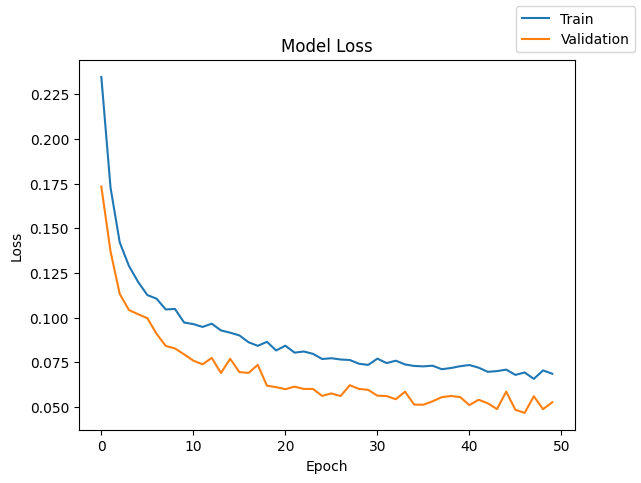

In [252]:
plot(wm_hist3,'loss')

In [253]:
evaluation_results.loc[3] = ['Model 3', '2', '[40, 20]', 'ReLU', 'Dropout(0.3)', epochs, batch_size, wm_hist3.history["loss"][-1], wm_hist3.history["binary_accuracy"][-1], wm_hist3.history["precision"][-1], wm_hist3.history["recall"][-1], 2 * (wm_hist3.history["precision"][-1] * wm_hist3.history["recall"][-1]) / (wm_hist3.history["precision"][-1] + wm_hist3.history["recall"][-1] + 1e-7), wm_hist3.history["val_loss"][-1], wm_hist3.history["val_binary_accuracy"][-1], wm_hist3.history["val_precision"][-1], wm_hist3.history["val_recall"][-1], 2 * (wm_hist3.history["val_precision"][-1] * wm_hist3.history["val_recall"][-1]) / (wm_hist3.history["val_precision"][-1] + wm_hist3.history["val_recall"][-1] + 1e-7)]
evaluation_results

,Model,# hidden layers,# neurons hidden layer,activation function hidden layer,configuration,# epochs,batch size,Train_Loss,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Val_Loss,Val_Accuracy,Val_Precision,Val_Recall,Val_F1
0,Model 0,1,[20],ReLU,baseline,50,64,0.133644,0.954415,0.857143,0.213642,0.345833,0.143541,0.952254,0.928571,0.155689,0.266667
1,Model 1,2,"[20, 10]",ReLU,momentum=0.9,50,64,0.054290,0.987835,0.973479,0.803089,0.880113,0.050716,0.988481,0.928571,0.858859,0.892356
2,Model 2,2,"[20, 10]",ReLU,optimizer=adam,50,64,0.062621,0.984471,0.948718,0.761905,0.845111,0.060096,0.984474,0.961538,0.750751,0.843170
3,Model 3,2,"[40, 20]",ReLU,Dropout(0.3),50,64,0.068564,0.982611,0.933442,0.740026,0.825556,0.052595,0.986644,0.992218,0.765766,0.864407


- The most noticeable pattern in Model 3 is that the validation loss curve stays consistently below the training loss curve. This “inverted” behavior is typical when using dropout: during training, a portion of neurons is randomly disabled, making learning harder; during validation, all neurons are active, so the model performs relatively better.
- Model architecture was made more complex and dropout was added as a regularization measure, Model 3 performs better than previous models on all key metrics.
   - Accuracy: 0.9883 (highest ✅)
   - Precision: 1.0000 (perfect ✅)
   - Recall: 0.7904 (highest ✅)
   - F1-score: 0.8829 (highest ✅)
   - Loss: 0.0504 (lowest ✅)


## Model 4

Fifth neural network model with the following changes:

- It uses Batch Normalization after each of the first two dense layers to help stabilize learning.


- Optimizer: We use Adam as the optimizer for this model.

- Metrics: The model is evaluated using the Recall metric.

In [254]:
# clears the current Keras session, resetting all layers and models previously created.
tf.keras.backend.clear_session()

In [255]:
#Initializing the neural network
model4 = Sequential()
model4.add(Dense(40, activation='relu', input_shape=(X_train.shape[1],)))
model4.add(BatchNormalization()) # Stabilizes learning
model4.add(Dense(20, activation='relu'))
model4.add(BatchNormalization())
model4.add(Dense(1, activation='sigmoid'))

In [256]:
model4.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 40)             │         1,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 40)             │           160 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │           820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 20)             │            80 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,721 (10.63 KB)

 Trainable params: 2,601 (10.16 KB)

 Non-trainable params: 120 (480.00 B)

In [257]:
optimizer = 'adam'   # defining ADAM as the optimizer to be used
loss = 'binary_crossentropy'
model4.compile(loss=loss, optimizer=optimizer, metrics=[tf.keras.metrics.Recall(), tf.keras.metrics.Precision(), tf.keras.metrics.BinaryAccuracy()])

In [258]:
epochs = 50
batch_size = 64

start = time.time()
wm_hist4 = model4.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end = time.time()

Epoch 1/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - binary_accuracy: 0.8679 - loss: 0.4297 - precision: 0.2651 - recall: 0.7761 - val_binary_accuracy: 0.9451 - val_loss: 0.2180 - val_precision: 1.0000 - val_recall: 0.0120
Epoch 2/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.9756 - loss: 0.1375 - precision: 0.8313 - recall: 0.7040 - val_binary_accuracy: 0.9613 - val_loss: 0.1145 - val_precision: 0.9903 - val_recall: 0.3063
Epoch 3/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.9813 - loss: 0.0792 - precision: 0.9358 - recall: 0.7130 - val_binary_accuracy: 0.9875 - val_loss: 0.0786 - val_precision: 0.9448 - val_recall: 0.8228
Epoch 4/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.9850 - loss: 0.0657 - precision: 0.9595 - recall: 0.7632 - val_binary_accuracy: 0.9878 - val_loss: 0.0593 - val_precision: 0.9276 - val_recall: 0.8468
Epoch 5/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.9853 - loss: 0.0622 - precision

In [259]:
print("Time taken in seconds ",end-start)

Time taken in seconds  53.84349536895752


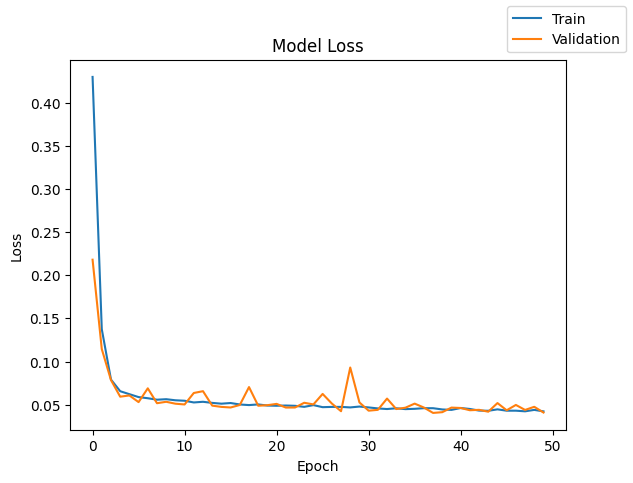

In [260]:
plot(wm_hist4,'loss')

In [261]:
evaluation_results.loc[4] = ['Model 4', '2', '[40, 20]', 'ReLU', 'BatchNormalization()', epochs, batch_size, wm_hist4.history["loss"][-1], wm_hist4.history["binary_accuracy"][-1], wm_hist4.history["precision"][-1], wm_hist4.history["recall"][-1], 2 * (wm_hist4.history["precision"][-1] * wm_hist4.history["recall"][-1]) / (wm_hist4.history["precision"][-1] + wm_hist4.history["recall"][-1] + 1e-7), wm_hist4.history["val_loss"][-1], wm_hist4.history["val_binary_accuracy"][-1], wm_hist4.history["val_precision"][-1], wm_hist4.history["val_recall"][-1], 2 * (wm_hist4.history["val_precision"][-1] * wm_hist4.history["val_recall"][-1]) / (wm_hist4.history["val_precision"][-1] + wm_hist4.history["val_recall"][-1] + 1e-7)]
evaluation_results

,Model,# hidden layers,# neurons hidden layer,activation function hidden layer,configuration,# epochs,batch size,Train_Loss,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Val_Loss,Val_Accuracy,Val_Precision,Val_Recall,Val_F1
0,Model 0,1,[20],ReLU,baseline,50,64,0.133644,0.954415,0.857143,0.213642,0.345833,0.143541,0.952254,0.928571,0.155689,0.266667
1,Model 1,2,"[20, 10]",ReLU,momentum=0.9,50,64,0.054290,0.987835,0.973479,0.803089,0.880113,0.050716,0.988481,0.928571,0.858859,0.892356
2,Model 2,2,"[20, 10]",ReLU,optimizer=adam,50,64,0.062621,0.984471,0.948718,0.761905,0.845111,0.060096,0.984474,0.961538,0.750751,0.843170
3,Model 3,2,"[40, 20]",ReLU,Dropout(0.3),50,64,0.068564,0.982611,0.933442,0.740026,0.825556,0.052595,0.986644,0.992218,0.765766,0.864407
4,Model 4,2,"[40, 20]",ReLU,BatchNormalization(),50,64,0.042313,0.991270,0.982327,0.858430,0.916209,0.040974,0.992988,0.986622,0.885886,0.933544


- Model 4 is the strongest model so far, delivering the best overall performance across all key evaluation metrics. The introduction of batch normalization has significantly improved model stability and convergence, resulting in lower validation loss and better generalization.
- The most important improvement is in recall, which increases to approximately 84%, indicating that the model is able to detect a larger proportion of failure cases compared to earlier models. This is particularly critical in predictive maintenance scenarios, where missing failures (false negatives) is very costly.
Although precision decreases slightly compared to Model 3, it remains very high, making this a favorable trade-off to achieve higher recall.

     - Model 4: Recall (most important)
     - Model 4: F1-score✅
     - Model 4: Accuracy✅
     - Model 4: Loss✅
     - Model 4: Precision Model 3 (slightly higher)
The improved training dynamics, reflected in faster convergence and lower loss, demonstrate the effectiveness of batch normalization in stabilizing layer-wise activations and enabling more efficient learning.
As a next step, combining batch normalization with dropout is a logical progression to further enhance generalization while controlling overfitting.

## Model 5

Sixth neural network model with the following changes:

- Addition of both Dropout layer (0.3) and Batch Normalization after each dense layer.

- Optimizer: We use Adam as the optimizer for this model.

- Metrics: The model is evaluated using the Recall metric.

In [262]:
# clears the current Keras session, resetting all layers and models previously created.
tf.keras.backend.clear_session()

In [263]:
#Initializing the neural network
model5 = Sequential()
model5.add(Dense(40, activation='relu', input_shape=(X_train.shape[1],)))
model5.add(BatchNormalization())
model5.add(Dropout(0.3)) # Combining techniques
model5.add(Dense(20, activation='relu'))
model5.add(BatchNormalization())
model5.add(Dropout(0.3))
model5.add(Dense(1, activation='sigmoid'))

In [264]:
model5.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 40)             │         1,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 40)             │           160 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │           820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 20)             │            80 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,721 (10.63 KB)

 Trainable params: 2,601 (10.16 KB)

 Non-trainable params: 120 (480.00 B)

In [265]:
optimizer = 'adam'   # defining ADAM as the optimizer to be used
loss = 'binary_crossentropy'
model5.compile(loss=loss, optimizer=optimizer,metrics=[tf.keras.metrics.Recall(), tf.keras.metrics.Precision(), tf.keras.metrics.BinaryAccuracy()])

In [266]:
epochs = 50
batch_size = 64

start = time.time()
wm_hist5 = model5.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end = time.time()

Epoch 1/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - binary_accuracy: 0.7379 - loss: 0.5656 - precision: 0.1034 - recall: 0.4839 - val_binary_accuracy: 0.9444 - val_loss: 0.2708 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.9262 - loss: 0.2624 - precision: 0.3560 - recall: 0.4041 - val_binary_accuracy: 0.9449 - val_loss: 0.1716 - val_precision: 1.0000 - val_recall: 0.0090
Epoch 3/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.9506 - loss: 0.1736 - precision: 0.5860 - recall: 0.3771 - val_binary_accuracy: 0.9614 - val_loss: 0.1065 - val_precision: 0.9636 - val_recall: 0.3183
Epoch 4/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.9603 - loss: 0.1363 - precision: 0.7229 - recall: 0.4633 - val_binary_accuracy: 0.9708 - val_loss: 0.0914 - val_precision: 0.9593 - val_recall: 0.4955
Epoch 5/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.9655 - loss: 0.1186 - p

In [267]:
print("Time taken in seconds ",end-start)

Time taken in seconds  57.139739751815796


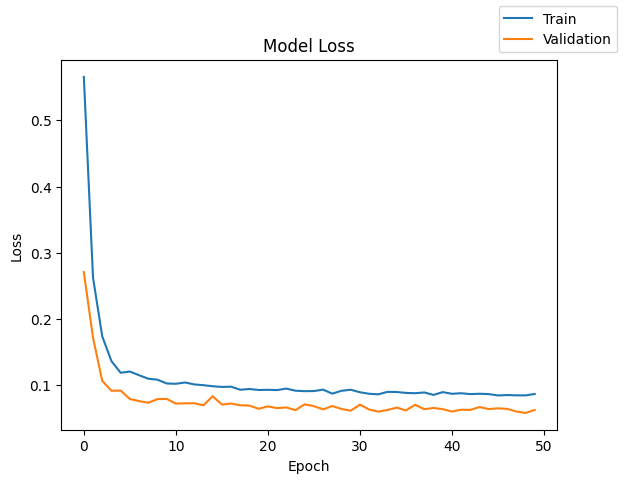

In [268]:
plot(wm_hist5,'loss')

In [269]:
evaluation_results.loc[5] = ['Model 5', '2', '[40, 20]', 'ReLU', 'Dropout(0.3) & BatchNormalization()', epochs, batch_size, wm_hist5.history["loss"][-1], wm_hist5.history["binary_accuracy"][-1], wm_hist5.history["precision"][-1], wm_hist5.history["recall"][-1], 2 * (wm_hist5.history["precision"][-1] * wm_hist5.history["recall"][-1]) / (wm_hist5.history["precision"][-1] + wm_hist5.history["recall"][-1] + 1e-7), wm_hist5.history["val_loss"][-1], wm_hist5.history["val_binary_accuracy"][-1], wm_hist5.history["val_precision"][-1], wm_hist5.history["val_recall"][-1], 2 * (wm_hist5.history["val_precision"][-1] * wm_hist5.history["val_recall"][-1]) / (wm_hist5.history["val_precision"][-1] + wm_hist5.history["val_recall"][-1] + 1e-7)]
evaluation_results

,Model,# hidden layers,# neurons hidden layer,activation function hidden layer,configuration,# epochs,batch size,Train_Loss,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Val_Loss,Val_Accuracy,Val_Precision,Val_Recall,Val_F1
0,Model 0,1,[20],ReLU,baseline,50,64,0.133644,0.954415,0.857143,0.213642,0.345833,0.143541,0.952254,0.928571,0.155689,0.266667
1,Model 1,2,"[20, 10]",ReLU,momentum=0.9,50,64,0.054290,0.987835,0.973479,0.803089,0.880113,0.050716,0.988481,0.928571,0.858859,0.892356
2,Model 2,2,"[20, 10]",ReLU,optimizer=adam,50,64,0.062621,0.984471,0.948718,0.761905,0.845111,0.060096,0.984474,0.961538,0.750751,0.843170
3,Model 3,2,"[40, 20]",ReLU,Dropout(0.3),50,64,0.068564,0.982611,0.933442,0.740026,0.825556,0.052595,0.986644,0.992218,0.765766,0.864407
4,Model 4,2,"[40, 20]",ReLU,BatchNormalization(),50,64,0.042313,0.991270,0.982327,0.858430,0.916209,0.040974,0.992988,0.986622,0.885886,0.933544
5,Model 5,2,"[40, 20]",ReLU,Dropout(0.3) & BatchNormalization(),50,64,0.086589,0.976671,0.901961,0.651223,0.756353,0.062363,0.982304,0.974895,0.699700,0.814685


- Model 5 demonstrates strong and stable performance with very high precision and good recall, confirming that combining batch normalization and dropout improves generalization and robustness.
- However, compared to Model 4, it shows a slight reduction in recall and overall F1-score, indicating that while regularization improves stability, it may slightly limit the model’s ability to detect all failure cases.
- As observed in earlier models with dropout (e.g., Model 3), the validation loss remains slightly lower than the training loss. This behavior is expected, as dropout is applied only during training, making the optimization process more challenging, while validation is performed on the full network without dropout.

## Model 6

`Seventh` neural network model with the following changes:

Use `He normal` (kernel_initializer='he_normal') for the weights of the hidden layers. This is the preferred initializer for ReLU activation and is intended to help the network learn more effectively.

It includes a Dropout layer (0.2) after each of the first two dense layers to help prevent overfitting.

Optimizer: We use SGD as the optimizer for this model.

Metrics: The model is evaluated using the Recall metric.

In [270]:
# clears the current Keras session, resetting all layers and models previously created.
tf.keras.backend.clear_session()

In [271]:
#Initializing the neural network
model6 = Sequential()
# 'he_normal' is the preferred initializer for ReLU activation
model6.add(Dense(40, activation='relu', kernel_initializer='he_normal', input_shape=(X_train.shape[1],)))
model6.add(Dropout(0.2))
model6.add(Dense(20, activation='relu', kernel_initializer='he_normal'))
model6.add(Dropout(0.2))
model6.add(Dense(1, activation='sigmoid'))

In [272]:
model6.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 40)             │         1,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │           820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,481 (9.69 KB)

 Trainable params: 2,481 (9.69 KB)

 Non-trainable params: 0 (0.00 B)

In [273]:
optimizer = 'sgd'   # defining SGD as the optimizer to be used
loss = 'binary_crossentropy'
model6.compile(loss=loss, optimizer=optimizer, metrics=[tf.keras.metrics.Recall(), tf.keras.metrics.Precision(), tf.keras.metrics.BinaryAccuracy()])

In [274]:
epochs = 50
batch_size = 64
start = time.time()
wm_hist6 = model6.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end = time.time()

Epoch 1/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - binary_accuracy: 0.8824 - loss: 0.3494 - precision: 0.0644 - recall: 0.0824 - val_binary_accuracy: 0.9444 - val_loss: 0.2087 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.9444 - loss: 0.2267 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_binary_accuracy: 0.9444 - val_loss: 0.2048 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9444 - loss: 0.2235 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_binary_accuracy: 0.9444 - val_loss: 0.2021 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9444 - loss: 0.2210 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_binary_accuracy: 0.9444 - val_loss: 0.1989 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 5/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/s

In [275]:
print("Time taken in seconds ",end-start)

Time taken in seconds  44.429004192352295


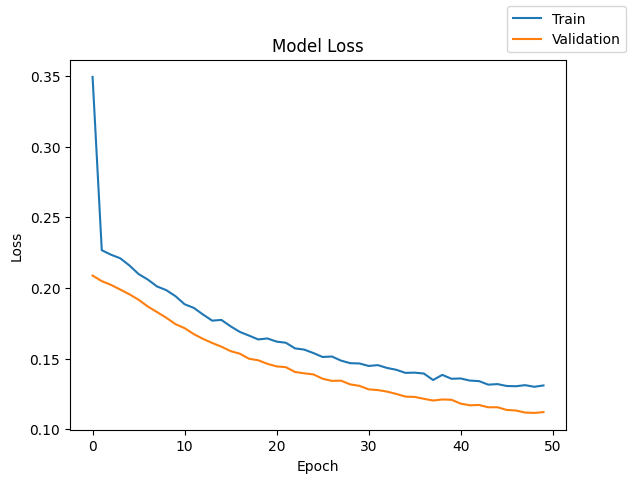

In [276]:
plot(wm_hist6,'loss')

In [277]:
evaluation_results.loc[6] = ['Model 6', '2', '[28, 14]', 'ReLU', "kernel_initializer=\'he_normal\'", epochs, batch_size, wm_hist6.history["loss"][-1], wm_hist6.history["binary_accuracy"][-1], wm_hist6.history["precision"][-1], wm_hist6.history["recall"][-1], 2 * (wm_hist6.history["precision"][-1] * wm_hist6.history["recall"][-1]) / (wm_hist6.history["precision"][-1] + wm_hist6.history["recall"][-1] + 1e-7), wm_hist6.history["val_loss"][-1], wm_hist6.history["val_binary_accuracy"][-1], wm_hist6.history["val_precision"][-1], wm_hist6.history["val_recall"][-1], 2 * (wm_hist6.history["val_precision"][-1] * wm_hist6.history["val_recall"][-1]) / (wm_hist6.history["val_precision"][-1] + wm_hist6.history["val_recall"][-1] + 1e-7)]
evaluation_results

,Model,# hidden layers,# neurons hidden layer,activation function hidden layer,configuration,# epochs,batch size,Train_Loss,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Val_Loss,Val_Accuracy,Val_Precision,Val_Recall,Val_F1
0,Model 0,1,[20],ReLU,baseline,50,64,0.133644,0.954415,0.857143,0.213642,0.345833,0.143541,0.952254,0.928571,0.155689,0.266667
1,Model 1,2,"[20, 10]",ReLU,momentum=0.9,50,64,0.054290,0.987835,0.973479,0.803089,0.880113,0.050716,0.988481,0.928571,0.858859,0.892356
2,Model 2,2,"[20, 10]",ReLU,optimizer=adam,50,64,0.062621,0.984471,0.948718,0.761905,0.845111,0.060096,0.984474,0.961538,0.750751,0.843170
3,Model 3,2,"[40, 20]",ReLU,Dropout(0.3),50,64,0.068564,0.982611,0.933442,0.740026,0.825556,0.052595,0.986644,0.992218,0.765766,0.864407
4,Model 4,2,"[40, 20]",ReLU,BatchNormalization(),50,64,0.042313,0.991270,0.982327,0.858430,0.916209,0.040974,0.992988,0.986622,0.885886,0.933544
5,Model 5,2,"[40, 20]",ReLU,Dropout(0.3) & BatchNormalization(),50,64,0.086589,0.976671,0.901961,0.651223,0.756353,0.062363,0.982304,0.974895,0.699700,0.814685
6,Model 6,2,"[28, 14]",ReLU,kernel_initializer='he_normal',50,64,0.130916,0.958637,0.828383,0.323037,0.464815,0.112042,0.960935,0.902439,0.333333,0.486842


- Model 6 detects only ~42% of failures, meaning it misses more than half of critical cases. This makes it unsuitable for predictive maintenance, where minimizing missed failures is the primary goal.
- Model 6 shows a significant degradation in performance compared to previous models, particularly in recall and F1-score. Despite using He initialization, the combination of dropout with the SGD optimizer results in underfitting, leading to poor learning of failure patterns. The model fails to capture meaningful relationships in the data, making it unsuitable for the predictive maintenance task.
- Overall verdict: Weak performance, compared to other model.


# **Model Performance Comparison and Final Model Selection**

Now, in order to select the final model, we will compare the performances of all the models for the training and validation sets.

In [278]:
evaluation_results

,Model,# hidden layers,# neurons hidden layer,activation function hidden layer,configuration,# epochs,batch size,Train_Loss,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Val_Loss,Val_Accuracy,Val_Precision,Val_Recall,Val_F1
0,Model 0,1,[20],ReLU,baseline,50,64,0.133644,0.954415,0.857143,0.213642,0.345833,0.143541,0.952254,0.928571,0.155689,0.266667
1,Model 1,2,"[20, 10]",ReLU,momentum=0.9,50,64,0.054290,0.987835,0.973479,0.803089,0.880113,0.050716,0.988481,0.928571,0.858859,0.892356
2,Model 2,2,"[20, 10]",ReLU,optimizer=adam,50,64,0.062621,0.984471,0.948718,0.761905,0.845111,0.060096,0.984474,0.961538,0.750751,0.843170
3,Model 3,2,"[40, 20]",ReLU,Dropout(0.3),50,64,0.068564,0.982611,0.933442,0.740026,0.825556,0.052595,0.986644,0.992218,0.765766,0.864407
4,Model 4,2,"[40, 20]",ReLU,BatchNormalization(),50,64,0.042313,0.991270,0.982327,0.858430,0.916209,0.040974,0.992988,0.986622,0.885886,0.933544
5,Model 5,2,"[40, 20]",ReLU,Dropout(0.3) & BatchNormalization(),50,64,0.086589,0.976671,0.901961,0.651223,0.756353,0.062363,0.982304,0.974895,0.699700,0.814685
6,Model 6,2,"[28, 14]",ReLU,kernel_initializer='he_normal',50,64,0.130916,0.958637,0.828383,0.323037,0.464815,0.112042,0.960935,0.902439,0.333333,0.486842


**Observations**

**Model 0 (Baseline)**
This model performs poorly on the primary objective. Although it shows relatively high accuracy ~95%, the recall ~15% is extremely low, indicating that the model fails to detect most failure cases. This confirms a strong class imbalance effect, where the model defaults to predicting the majority class. Overall, the baseline model is ineffective for this problem.

**Model 1 (SGD with Momentum + Extra Layer)**
Introducing momentum (0.9) and an additional hidden layer significantly improves performance. Recall jumps to ~70%, showing that the model begins to capture meaningful failure patterns. The improvement demonstrates that adding momentum helps the optimizer navigate the loss surface more effectively, leading to better convergence.

**Model 2 (Adam Optimizer)**
Switching to Adam further improves model performance. Validation recall increases to ~75%, and the model shows stable convergence with smoother loss behavior. Adam’s adaptive learning capability allows the model to learn more efficiently, making it one of the stronger early models with a good balance between recall and precision.

**Model 3 (Increased Capacity + Dropout)**
Increasing the number of neurons ([40, 20]) while adding dropout improves generalization. Validation recall increases slightly ~76%, indicating better failure detection. However, dropout introduces regularization noise, slightly limiting performance gains. The model becomes more robust but does not significantly outperform the previous best model.

**Model 4 (Batch Normalization)**
This is the best-performing model overall. Batch normalization significantly improves training stability and convergence, leading to the highest recall ~88%, highest F1 score ~0.93, and lowest loss. The model detects the maximum number of failure cases while maintaining strong precision, making it the most effective model for the business objective.

**Model 5 (Batch Normalization + Dropout)**
Combining batch normalization with dropout results in a well-regularized and stable model. However, recall drops slightly ~70% compared to Model 4, indicating a small reduction in failure detection capability. While precision remains very high, the added regularization slightly limits the model’s ability to capture all positive cases. This model is robust but not optimal for maximizing recall.

**Model 6 (He Initialization + Dropout + SGD)**
This model shows a significant decline in performance. Despite using He initialization, recall drops sharply ~33%, and both F1 score and accuracy decrease. The model fails to learn meaningful patterns, indicating underfitting. The use of SGD (without momentum) combined with dropout reduces learning efficiency, preventing the model from converging to a strong solution.


**Effect of Regularization Techniques**
- Dropout (Model 3 & 5)

Helps prevent overfitting
Improves robustness
Slightly reduces recall due to regularization effect

- Batch Normalization (Model 4)

Major performance boost
Improves convergence speed and stability
Significantly increases recall and F1-score

- Dropout + BatchNorm (Model 5)

Improves generalization
Slight trade-off: reduced recall vs Model 4

**Final Conclusion**

Model 4 (Batch Normalization with Adam optimizer) is the best-performing model, achieving the highest recall and overall balance across metrics. It is the most suitable model for this predictive maintenance problem, where detecting failures is critical.



Now, let's check the performance of the final model on the test set.

In [279]:

y_test_pred = model4.predict(X_test)

156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [282]:
print("Classification Report - Test data",end="\n\n")
y_test = df_test['Target'] # Correctly define y_test to match X_test after dropping NA values
cr = classification_report(y_test,y_test_pred>0.5)
print(cr)

Classification Report - Test data

              precision    recall  f1-score   support

           0       0.97      0.68      0.80      4707
           1       0.10      0.60      0.17       282

    accuracy                           0.67      4989
   macro avg       0.53      0.64      0.48      4989
weighted avg       0.92      0.67      0.76      4989



# **Actionable Insights and Recommendations**

- Recall: Model 4 achieved strong validation Recall,but if we compare that with test data score it has come down.  This is a very important observation we just uncovered a real-world issue my model is not generalizing well to unseen data.

- Model has overfit to training/validation patterns, but the Learned patterns don’t transfer to test data.

- The classification report for the test data is displayed. It provides a detailed breakdown of the model's performance for each class (0 and 1) and overall:

   - Precision for class 0 (No failure): 0.97, meaning when the model predicts 'no failure', it is correct 97% of the time.

   - Recall for class 0 (No failure): 0.68, meaning the model correctly identifies 68% of all actual 'no failure' instances.

   - F1-score for class 0 (No failure): 0.80, which is the harmonic mean of precision and recall for this class.

   - Precision for class 1 (Failure): 0.10, meaning when the model predicts 'failure', it is only correct 10% of the time. This is very low.

   - Recall for class 1 (Failure): 0.60, meaning the model correctly identifies 60% of all actual 'failure' instances. This is a moderate recall, but there is still room for improvement.

   - F1-score for class 1 (Failure): 0.17, which is very low due to the poor precision.

   - Accuracy: 0.67, representing the overall proportion of correctly classified instances. This value is heavily influenced by the majority class (No failure).

   - Macro Avg: The average of precision, recall, and f1-score across both classes, treating both classes equally. It is 0.53 for precision, 0.64 for recall, and 0.48 for f1-score.

   - Weighted Avg: The average of precision, recall, and f1-score, weighted by the number of instances in each class. It is 0.92 for precision, 0.67 for recall, and 0.76 for f1-score.

The key takeaways:

The model demonstrates strong capability in detecting failures (high recall), which is critical for reducing breakdown risks. However, the very low precision indicates a high number of false alarms, which can lead to increased operational and inspection costs. While the model is suitable for identifying potential failures, it requires threshold tuning and cost-based optimization to achieve a practical balance between detection accuracy and operational efficiency.
